loading

In [ ]:
# This will change Colab runtime to 3.10 (requires reconnect)
!sudo apt-get update -y
!sudo apt-get install python3.10 python3.10-dev python3.10-distutils -y
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 1


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,592 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,864 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,637 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [69.2 kB]
Get:14 http://ar

In [ ]:
!pip install numpy==1.26.4 scikit-learn==1.3.2 scikit-learn-extra


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 17.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 113.0 MB/s eta 0:00:00
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=1959516 sha256=54aa0183c107ab1a46cddec2389e59fa68e6acca094e6aaaa25d61bf00edf333
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing install

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


loading

In [ ]:
import pandas as pd
# Load
save_path = "/content/drive/MyDrive/project/df_encoded.parquet"
df_encoded = pd.read_parquet(save_path, engine='pyarrow')
print("Loaded DataFrame shape:", df_encoded.shape)


Loaded DataFrame shape: (428959, 58)


In [ ]:
import pandas as pd
# Load
save_path = "/content/drive/MyDrive/project/df_all.parquet"
df_all = pd.read_parquet(save_path, engine='pyarrow')
print("Loaded DataFrame shape:", df_all.shape)

Loaded DataFrame shape: (428959, 61)


scaling + to numpy

In [ ]:
from sklearn.preprocessing import StandardScaler

# ----------------------------------------
# 1️⃣ Initialize the scaler
scaler = StandardScaler()

# 2️⃣ Fit & transform the dataframe
X_scaled = scaler.fit_transform(df_encoded)

# 3️⃣ Convert to NumPy array (already done by StandardScaler)
X_np = X_scaled

# Optional: check shape and type
print("Shape:", X_np.shape)
print("Type:", type(X_np))
print("Example data (first 5 rows):\n", X_np[:5])


Shape: (428959, 58)
Type: <class 'numpy.ndarray'>
Example data (first 5 rows):
 [[-4.23409600e-01 -7.04182488e-01 -2.10074798e-01 -5.85971548e-01
   3.98840860e-01  4.46792944e-01  5.50507339e-01  2.63428047e-01
  -1.42595246e-01  4.18029035e-01  5.59331780e-01  7.30149369e-02
   3.65478577e-01  1.19864222e+00  1.15839784e+00 -6.15751299e-01
  -4.49341323e-01 -8.07028231e-01  1.20383762e-01  9.90316013e-01
  -8.26771393e-01  3.93212129e-01 -6.97035822e-02 -1.69941775e+00
   1.65725321e-01 -5.83190872e-01  2.28385339e+00 -1.41481706e-01
  -1.14131135e+00 -1.91922095e-01  4.74037816e-01 -2.01686999e-01
  -3.47711751e-02 -3.44211772e-01 -4.16265100e-02 -1.66122986e-01
  -2.14545348e-01 -1.21536750e-01 -5.20226618e-01 -1.11162134e-02
  -1.11001319e-01 -2.13902536e-01 -1.81176205e-01 -8.21575231e-02
  -7.97209208e-02 -1.19258106e-02 -1.52683678e-03 -4.83633599e-02
  -4.03965867e-03 -1.89509262e-02 -4.13162749e-02 -7.01297767e-01
   1.67741309e+00 -6.99700825e-03 -5.63547502e-02 -3.29068348e

In [ ]:
import numpy as np
from sklearn_extra.cluster import KMedoids
from tqdm import tqdm
import time
import gc  # garbage collector

# ----------------------------
# INPUT DATA
# ----------------------------
X = X_np.astype(np.float32)  # scaled features in float32 for memory

# ----------------------------
# GRID SEARCH PARAMETERS
# ----------------------------
n_clusters_list = [3, 4, 5]         # try more later
metric_list = ["manhattan"]         # stick to geo-friendly metric
init_list = ["k-medoids++"]         # single init for speed
subsample_size = 20000               # smaller subsample to save RAM
n_subsamples = 3                     # fewer subsamples per combo
batch_size = 5000                    # batch size for distance computation

# ----------------------------
# GRID SEARCH
# ----------------------------
results = []

total_combos = len(n_clusters_list) * len(metric_list) * len(init_list)
with tqdm(total=total_combos, desc="Grid Search") as pbar_combo:
    for n_clusters in n_clusters_list:
        for metric in metric_list:
            for init in init_list:

                best_total_distance = np.inf
                best_labels = None
                combo_start = time.time()

                for i in range(n_subsamples):
                    sub_start = time.time()

                    # Subsample
                    idxs = np.random.choice(X.shape[0], min(subsample_size, X.shape[0]), replace=False)
                    X_sub = X[idxs]

                    # Fit KMedoids
                    model = KMedoids(
                        n_clusters=n_clusters,
                        method="pam",
                        metric=metric,
                        init=init,
                        random_state=42
                    )
                    model.fit(X_sub)

                    # Assign all points to nearest medoid (batched)
                    medoids = X_sub[model.medoid_indices_]
                    labels_full = np.empty(X.shape[0], dtype=np.int32)
                    total_distance = 0
                    for start in range(0, X.shape[0], batch_size):
                        end = min(start+batch_size, X.shape[0])
                        batch = X[start:end]
                        dists = np.abs(batch[:, None, :] - medoids[None, :, :]).sum(axis=2)
                        labels_full[start:end] = np.argmin(dists, axis=1)
                        total_distance += dists.min(axis=1).sum()

                    # Keep best medoids
                    if total_distance < best_total_distance:
                        best_total_distance = total_distance
                        best_labels = labels_full

                    sub_end = time.time()
                    print(f"Subsample {i+1}/{n_subsamples} done in {sub_end - sub_start:.2f}s")

                    # Clean memory between subsamples
                    del X_sub, model, dists, batch
                    gc.collect()

                combo_end = time.time()
                print(f"Combo n_clusters={n_clusters}, metric={metric}, init={init} done in {combo_end - combo_start:.2f}s\n")

                # Save best labels and total distance for metrics cell
                results.append({
                    "n_clusters": n_clusters,
                    "metric": metric,
                    "init": init,
                    "labels": best_labels,
                    "total_distance": best_total_distance
                })

                # Clear memory after each combo
                del best_labels
                gc.collect()

                pbar_combo.update(1)

import os
import pandas as pd

save_dir = "/content/drive/MyDrive/project"
os.makedirs(save_dir, exist_ok=True)

# ----------------------------
# Save metrics (safe)
# ----------------------------
metrics_df = pd.DataFrame([
    {
        "n_clusters": r["n_clusters"],
        "metric": r["metric"],
        "init": r["init"],
        "total_distance": r["total_distance"]
    }
    for r in results
])

metrics_path = os.path.join(save_dir, "clara_metrics.parquet")
metrics_df.to_parquet(metrics_path, engine="pyarrow")

# ----------------------------
# Save labels (safe)
# ----------------------------
labels_frames = []

for r in results:
    df_labels = pd.DataFrame({
        "index": range(len(r["labels"])),
        "cluster": r["labels"]
    })
    df_labels["n_clusters"] = r["n_clusters"]
    df_labels["metric"] = r["metric"]
    df_labels["init"] = r["init"]

    labels_frames.append(df_labels)

labels_df = pd.concat(labels_frames, ignore_index=True)

labels_path = os.path.join(save_dir, "clara_labels.parquet")
labels_df.to_parquet(labels_path, engine="pyarrow")

print("Saved safely (NumPy-independent):")
print(metrics_path)
print(labels_path)



Grid Search:   0%|          | 0/3 [00:00<?, ?it/s]

Subsample 1/3 done in 145.52s
Subsample 2/3 done in 164.04s


Grid Search:  33%|███▎      | 1/3 [08:25<16:51, 505.74s/it]

Subsample 3/3 done in 195.76s
Combo n_clusters=3, metric=manhattan, init=k-medoids++ done in 505.64s

Subsample 1/3 done in 328.94s
Subsample 2/3 done in 212.91s


Grid Search:  67%|██████▋   | 2/3 [22:11<11:33, 693.69s/it]

Subsample 3/3 done in 282.99s
Combo n_clusters=4, metric=manhattan, init=k-medoids++ done in 825.17s

Subsample 1/3 done in 393.55s
Subsample 2/3 done in 451.85s


Grid Search: 100%|██████████| 3/3 [42:20<00:00, 846.88s/it]

Subsample 3/3 done in 363.84s
Combo n_clusters=5, metric=manhattan, init=k-medoids++ done in 1209.56s



Saved safely (NumPy-independent):
/content/drive/MyDrive/project/clara_metrics.parquet
/content/drive/MyDrive/project/clara_labels.parquet


metrics

In [ ]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
import pandas as pd

# ----------------------------
# COMPUTE METRICS
# ----------------------------
results_metrics = []

for r in results:
    labels = r["labels"]

    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    results_metrics.append({
        "n_clusters": r["n_clusters"],
        "metric": r["metric"],
        "init": r["init"],
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "total_distance": r["total_distance"]
    })

results_df = pd.DataFrame(results_metrics)

# ----------------------------
# BEST PARAMETERS
# ----------------------------

best_db = results_df.loc[results_df["davies_bouldin"].idxmin()]
best_ch = results_df.loc[results_df["calinski_harabasz"].idxmax()]

print("Best parameters by Davies-Bouldin (LOWER is better):")
print(best_db, "\n")

print("Best parameters by Calinski-Harabasz (HIGHER is better):")
print(best_ch)

results_df



Best parameters by Davies-Bouldin (LOWER is better):
n_clusters                        4
metric                    manhattan
init                    k-medoids++
davies_bouldin             1.803884
calinski_harabasz      51301.834103
total_distance       7106680.703125
Name: 1, dtype: object 

Best parameters by Calinski-Harabasz (HIGHER is better):
n_clusters                        3
metric                    manhattan
init                    k-medoids++
davies_bouldin             2.224456
calinski_harabasz      52746.020463
total_distance       7994987.859375
Name: 0, dtype: object


,n_clusters,metric,init,davies_bouldin,calinski_harabasz,total_distance
0,3,manhattan,k-medoids++,2.224456,52746.020463,7.994988e+06
1,4,manhattan,k-medoids++,1.803884,51301.834103,7.106681e+06
2,5,manhattan,k-medoids++,2.061044,47897.553301,6.618311e+06


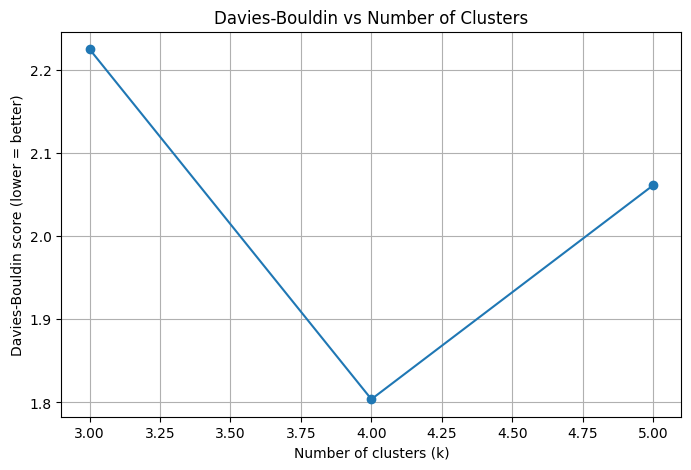

In [ ]:
import matplotlib.pyplot as plt

# Average scores per k (in case you test multiple runs later)
grouped = results_df.groupby("n_clusters").mean(numeric_only=True)

plt.figure(figsize=(8, 5))
plt.plot(grouped.index, grouped["davies_bouldin"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin score (lower = better)")
plt.title("Davies-Bouldin vs Number of Clusters")
plt.grid(True)
plt.show()


Clustering Evaluation and Selection of k

To determine the optimal number of clusters, a CLARA-like approach based on K-Medoids was employed due to the large size and geographical nature of the dataset. Unlike K-Means, K-Medoids is more robust to outliers and better suited for non-Euclidean distance metrics such as Manhattan distance.

Multiple internal clustering validation metrics were used:

Davies–Bouldin Index (DB): measures intra-cluster compactness and inter-cluster separation (lower values indicate better clustering).

Calinski–Harabasz Index (CH): evaluates the ratio of between-cluster dispersion to within-cluster dispersion (higher values indicate better-defined clusters).

Total distance to medoids: measures overall cluster compactness (lower values indicate better clustering).

The results are summarized below:

k	Davies–Bouldin ↓	Calinski–Harabasz ↑	Total Distance ↓
3	2.224	52,746	7,994,988
4	1.804	51,302	7,106,681
5	2.061	47,898	6,618,311

Although k = 3 achieved the highest Calinski–Harabasz score, it also exhibited a significantly higher Davies–Bouldin index, indicating weaker cluster separation.
The configuration k = 4 achieved the lowest Davies–Bouldin index, representing the best balance between cluster compactness and separation, while also substantially reducing the total distance to medoids.

Therefore, k = 4 was selected as the optimal number of clusters.

FINAL EXECUTION FOR k = 4 (CLARA-STYLE)

In [ ]:
import time
import gc

# ----------------------------
# INPUT DATA
# ----------------------------
X = X_np.astype(np.float32)

# ----------------------------
# FINAL PARAMETERS
# ----------------------------
n_clusters = 4
metric = "manhattan"
init = "k-medoids++"
subsample_size = 20000
n_subsamples = 3
batch_size = 5000

best_total_distance = np.inf
best_labels = None

start_time = time.time()

for i in range(n_subsamples):
    print(f"Running subsample {i+1}/{n_subsamples}")

    idxs = np.random.choice(X.shape[0], min(subsample_size, X.shape[0]), replace=False)
    X_sub = X[idxs]

    model = KMedoids(
        n_clusters=n_clusters,
        method="pam",
        metric=metric,
        init=init,
        random_state=42
    )
    model.fit(X_sub)

    medoids = X_sub[model.medoid_indices_]

    labels_full = np.empty(X.shape[0], dtype=np.int32)
    total_distance = 0

    for start in range(0, X.shape[0], batch_size):
        end = min(start + batch_size, X.shape[0])
        batch = X[start:end]
        dists = np.abs(batch[:, None, :] - medoids[None, :, :]).sum(axis=2)
        labels_full[start:end] = np.argmin(dists, axis=1)
        total_distance += dists.min(axis=1).sum()

    if total_distance < best_total_distance:
        best_total_distance = total_distance
        best_labels = labels_full

    del X_sub, model, dists, batch
    gc.collect()

end_time = time.time()

print(f"Final CLARA-like K-Medoids (k=4) completed in {end_time - start_time:.2f}s")

labels_k4 = best_labels

Running subsample 1/3
Running subsample 2/3
Running subsample 3/3
Final CLARA-like K-Medoids (k=4) completed in 757.04s


save

In [ ]:
import pandas as pd

save_path = "/content/drive/MyDrive/project/labels_clara_k4.csv"

labels_df = pd.DataFrame({
    "clara_cluster": labels_k4
})

labels_df.to_csv(save_path, index=False)

print("Labels saved to:", save_path)


Labels saved to: /content/drive/MyDrive/project/labels_clara_k4.csv


clara from scratch

CLARANS is a randomized clustering algorithm belonging to the k-medoids family.
Instead of exhaustively evaluating all possible medoid swaps (as in PAM), CLARANS explores the search space by randomly sampling a limited number of neighbors.
This makes it suitable for large datasets while keeping memory usage low.
The algorithm iteratively replaces medoids if a random swap leads to a lower clustering cost, and restarts the process multiple times to avoid local minima.

In [ ]:
import numpy as np
from tqdm import trange

# =====================================================
# VECTOR-FRIENDLY MANHATTAN DISTANCE
# =====================================================
def assign_clusters_vectorized(X, medoid_indices):
    """
    Assign points to the nearest medoid (vectorized).
    Returns: labels, total_cost
    """
    # Compute Manhattan distance from all points to all medoids
    # X: (n_samples, n_features)
    # medoid_indices: indices of current medoids
    dists = np.sum(np.abs(X[:, np.newaxis, :] - X[medoid_indices]), axis=2)  # shape: (n_samples, n_clusters)

    labels = np.argmin(dists, axis=1)
    total_cost = np.sum(dists[np.arange(X.shape[0]), labels])
    return labels, total_cost

# =====================================================
# FAST CLARANS
# =====================================================
def clarans(X, n_clusters, max_neighbors=20, num_local=3, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    best_global_cost = np.inf
    best_global_medoids = None
    best_global_labels = None

    # Outer loop: local minima search
    for local_iter in trange(num_local, desc="Local Search", leave=True):
        # Random initialization of medoids
        medoid_indices = np.random.choice(n_samples, n_clusters, replace=False)
        labels, current_cost = assign_clusters_vectorized(X, medoid_indices)

        # Inner loop: neighbor swaps
        for neighbor_iter in trange(max_neighbors, desc=f"Neighbors (Local {local_iter+1})", leave=False):
            # Pick random medoid to replace
            medoid_out = np.random.choice(medoid_indices)
            # Pick random non-medoid
            medoid_in = np.random.choice(np.setdiff1d(np.arange(n_samples), medoid_indices, assume_unique=True))

            # Swap in place
            swap_idx = np.where(medoid_indices == medoid_out)[0][0]
            medoid_indices[swap_idx] = medoid_in

            # Evaluate new configuration
            new_labels, new_cost = assign_clusters_vectorized(X, medoid_indices)

            if new_cost < current_cost:
                # Accept swap
                current_cost = new_cost
                labels = new_labels
            else:
                # Revert swap
                medoid_indices[swap_idx] = medoid_out

        # Update global best after local search
        if current_cost < best_global_cost:
            best_global_cost = current_cost
            best_global_medoids = medoid_indices.copy()
            best_global_labels = labels.copy()

    return best_global_labels, best_global_medoids, best_global_cost



In [ ]:

# =====================================================
# EXECUTION FOR k = 4
# =====================================================
k = 4

labels_clarans, medoids_clarans, cost_clarans = clarans(
    X_np,
    n_clusters=k,
    max_neighbors=20,
    num_local=3,
    random_state=42
)

print("CLARANS finished")
print("Medoid indices:", medoids_clarans)
print("Total cost:", cost_clarans)


import pandas as pd

# Convert labels to DataFrame
labels_df = pd.DataFrame({"label": labels_clarans})

# Save to CSV on Google Drive
save_path = "/content/drive/MyDrive/project/clarans_labels_k4.csv"
labels_df.to_csv(save_path, index=False)

print(f"Labels saved to {save_path}")

Local Search: 100%|██████████| 3/3 [00:57<00:00, 19.26s/it]


CLARANS finished
Medoid indices: [ 38257  44037 291040 195253]
Total cost: 7678651.986749874
Labels saved to /content/drive/MyDrive/project/clarans_labels_k4.csv
